# Partie 1: Listings Airbnb Septembre 2024

## 1.Importations des bibliothéques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# 2. Importations des données et premières informations

In [2]:
df=pd.read_csv("DATA_sept_2024/listings_sept_2024.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,371299,Marais Rue des Archives refait à neuf février ...,1870265,Thomas,NaN,Hôtel-de-Ville,48.85751,2.35511,Entire home/apt,185.0,3,601,2024-09-06,3.97,3,307,54,7510300547558
1,371862,loft in Paris (Belleville),1872631,Veronique,NaN,Entrepôt,48.87151,2.37219,Entire home/apt,250.0,4,50,2023-08-14,0.34,1,9,0,7511000320406
2,372879,Appartement complet au centre de Paris.,1876396,Samuel,NaN,Gobelins,48.83593,2.35108,Entire home/apt,85.0,30,171,2024-08-15,2.01,3,151,1,"Available with a mobility lease only (""bail mo..."
3,375434,"Luxurious Art & Design Flat, 180m2, Champs Ely...",683140,Oscar,NaN,Élysée,48.86680,2.30972,Entire home/apt,NaN,3,22,2023-07-15,0.15,1,0,0,7510806561916
4,378897,Little flat near Montmartre,1902818,Lorraine,NaN,Opéra,48.88285,2.33462,Entire home/apt,110.0,3,28,2024-07-30,0.19,1,6,2,7511805895013


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95461 entries, 0 to 95460
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              95461 non-null  int64  
 1   name                            95461 non-null  object 
 2   host_id                         95461 non-null  int64  
 3   host_name                       95455 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   95461 non-null  object 
 6   latitude                        95461 non-null  float64
 7   longitude                       95461 non-null  float64
 8   room_type                       95461 non-null  object 
 9   price                           64230 non-null  float64
 10  minimum_nights                  95461 non-null  int64  
 11  number_of_reviews               95461 non-null  int64  
 12  last_review                     

#### Toutes les colonnes ne sont pas utiles pour notre étude, nous allons les supprimer. Puis nous traiterons les valeurs manquantes . Avant cela nous allons filtrer les données pour notre étude.

In [5]:
cols_to_keep = [
    "id", "neighbourhood", "latitude", "longitude", 
    "room_type", "price", "availability_365", 
    "number_of_reviews", "reviews_per_month", "minimum_nights"]

In [6]:
df = df[cols_to_keep]

In [7]:
df.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
0,371299,Hôtel-de-Ville,48.85751,2.35511,Entire home/apt,185.0,307,601,3.97,3
1,371862,Entrepôt,48.87151,2.37219,Entire home/apt,250.0,9,50,0.34,4
2,372879,Gobelins,48.83593,2.35108,Entire home/apt,85.0,151,171,2.01,30
3,375434,Élysée,48.86680,2.30972,Entire home/apt,NaN,0,22,0.15,3
4,378897,Opéra,48.88285,2.33462,Entire home/apt,110.0,6,28,0.19,3


## 3. Filtrages nécessaires à notre étude

In [8]:
df = df[
    (df['latitude'] >= 48.81) & (df['latitude'] <= 48.90) &
    (df['longitude'] >= 2.25) & (df['longitude'] <= 2.42)
] # Notre choix d'étude est Paris intra-muros dont on peut trouver les latitudes et longitudes correspondantes

In [9]:
df = df[df['availability_365'] > 0] # on ne garde que les logements actifs

In [10]:
df = df[
    (df['room_type'] == "Entire home/apt") &
    (df['minimum_nights'] <= 30)
]  # les logements entiers sont les plus representatifs et les plus recherchés par les touristes et ceux-ci n'effectuent pas de sejours longue durée

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55988 entries, 0 to 95459
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 55988 non-null  int64  
 1   neighbourhood      55988 non-null  object 
 2   latitude           55988 non-null  float64
 3   longitude          55988 non-null  float64
 4   room_type          55988 non-null  object 
 5   price              53818 non-null  float64
 6   availability_365   55988 non-null  int64  
 7   number_of_reviews  55988 non-null  int64  
 8   reviews_per_month  40649 non-null  float64
 9   minimum_nights     55988 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 4.7+ MB


In [12]:
df_sans_doublons=df.drop_duplicates()

In [13]:
df_sans_doublons.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55988 entries, 0 to 95459
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 55988 non-null  int64  
 1   neighbourhood      55988 non-null  object 
 2   latitude           55988 non-null  float64
 3   longitude          55988 non-null  float64
 4   room_type          55988 non-null  object 
 5   price              53818 non-null  float64
 6   availability_365   55988 non-null  int64  
 7   number_of_reviews  55988 non-null  int64  
 8   reviews_per_month  40649 non-null  float64
 9   minimum_nights     55988 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 4.7+ MB


#### Il n'y avait pas de doublons dans le dataset

## 4. Gestions des valeurs manquantes

#### La colonne 'Price' contient beaucoup de valeurs manquantes ( 2170) mais étant donné la taille du Dataset la perte de ces données est négligeable(moins de 4%) , nous allons donc supprimer ces lignes ,c'est plus simple,plus propre pour une colonne qui a son importance.

In [14]:
df = df.dropna(subset=['price'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53818 entries, 0 to 95459
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 53818 non-null  int64  
 1   neighbourhood      53818 non-null  object 
 2   latitude           53818 non-null  float64
 3   longitude          53818 non-null  float64
 4   room_type          53818 non-null  object 
 5   price              53818 non-null  float64
 6   availability_365   53818 non-null  int64  
 7   number_of_reviews  53818 non-null  int64  
 8   reviews_per_month  39046 non-null  float64
 9   minimum_nights     53818 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 4.5+ MB


#### Pour la colonne 'reviews_per_months' nous allons laisser la mention Nan qui peut prendre tout son sens surtout sil ny a jamais eu d'avis.Ou nous reviendrons plus tard sur cette décision

In [16]:
nan_reviews_per_month = df[df['reviews_per_month'].isna()]
print(nan_reviews_per_month['number_of_reviews'].value_counts())

number_of_reviews
0    14772
Name: count, dtype: int64


#### Donc en effet ces valeurs manquantes correspondent au fait qu'il n'y a aucun avis . On va donc les laisser et ajouter plus tard si besoin une colonne stipulant l'absence d'avis.

## 5. Statistiques descriptives et gestion des potentiels outliers

In [17]:
df.describe()

,id,latitude,longitude,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
count,5.381800e+04,53818.000000,53818.000000,53818.000000,53818.000000,53818.000000,39046.000000,53818.000000
mean,7.449637e+17,48.863865,2.341737,263.738396,184.445632,23.952451,1.352887,5.180126
std,4.648927e+17,0.017916,0.034347,527.780941,117.189961,52.379527,1.297533,8.024300
min,3.109000e+03,48.816090,2.250700,8.000000,1.000000,0.000000,0.010000,1.000000
25%,5.341099e+07,48.850864,2.319180,109.000000,76.000000,0.000000,0.440000,2.000000
50%,9.542663e+17,48.864980,2.345950,160.000000,180.000000,5.000000,0.970000,3.000000
75%,1.115806e+18,48.878120,2.366252,266.000000,282.000000,24.000000,1.840000,4.000000
max,1.239137e+18,48.899990,2.416250,30400.000000,365.000000,930.000000,19.120000,30.000000


#### Dans la colonne prix par exemple la lecture du troisième quartile nous indique clairement que le maximum est une valeur aberrante.Nous allons détecter ces valeurs extrêmes dans les colonnes 'price' ,'minimum_nights'.

In [18]:
colonnes_à_traiter = ['price',  'minimum_nights']

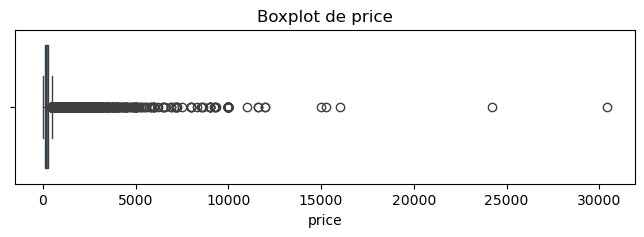

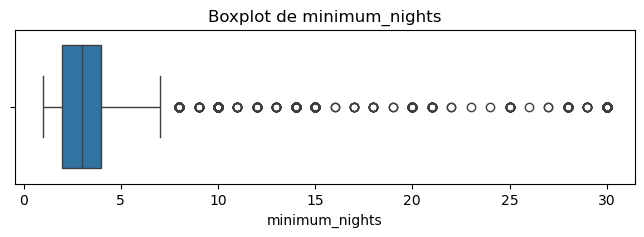

In [19]:
for col in colonnes_à_traiter:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

#### Effectivement les boxplot nous indiquent un très grand nombre de valeurs extrêmes. Il pourrait s'agir d'erreurs de saisies,de quelques logements très luxueux , très demandés ou atypiques.

In [20]:
outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns) # Un dataframe où 'False' sera remplacé par 'true' si un outlier est détecté
for col in colonnes_à_traiter :  # on  vérifie toutes les colonnes numériques sauf les colonnes binaires
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR     # calcul des quartiles et des bornes
    outlier_mask[col] = (df[col] < borne_inf) | (df[col] > borne_sup)  # le masque passera à true pour les cellules dont la valeur qui ne sont pas dans la borne
outliers = df[outlier_mask.any(axis=1)]
print("Valeurs aberrantes détectées :")
print(outliers)

Valeurs aberrantes détectées :
                        id   neighbourhood   latitude  longitude  \
2                   372879        Gobelins  48.835930   2.351080   
5                   379527        Entrepôt  48.869600   2.353070   
12                  396057          Temple  48.862600   2.362050   
37                  420805          Temple  48.860640   2.357320   
38                  420981        Entrepôt  48.872780   2.372210   
...                    ...             ...        ...        ...   
95440  1236796766448659282          Élysée  48.873627   2.303860   
95446  1236866520838778831        Entrepôt  48.872456   2.355271   
95449  1236880842071126487          Temple  48.860940   2.364710   
95452  1236888725407652269        Entrepôt  48.879876   2.354302   
95459  1236994124224110652  Palais-Bourbon  48.857622   2.303587   

             room_type  price  availability_365  number_of_reviews  \
2      Entire home/apt   85.0               151                171   
5      Entir

#### Supprimer 9716 lignes où apparaissent au moins un outlier est beucoup (un peu moins de 20% des données) mais pour mon étude et pour les visualisations je veux des données fiables

In [21]:
df_clean = df[~outlier_mask.any(axis=1)]

In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44102 entries, 0 to 95458
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 44102 non-null  int64  
 1   neighbourhood      44102 non-null  object 
 2   latitude           44102 non-null  float64
 3   longitude          44102 non-null  float64
 4   room_type          44102 non-null  object 
 5   price              44102 non-null  float64
 6   availability_365   44102 non-null  int64  
 7   number_of_reviews  44102 non-null  int64  
 8   reviews_per_month  33897 non-null  float64
 9   minimum_nights     44102 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 3.7+ MB


In [23]:
df_clean.describe()

,id,latitude,longitude,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
count,4.410200e+04,44102.000000,44102.000000,44102.00000,44102.000000,44102.000000,33897.000000,44102.000000
mean,7.450829e+17,48.864242,2.343833,188.07952,177.114303,26.696703,1.453635,2.539454
std,4.650924e+17,0.018203,0.033887,102.16419,118.584956,55.361364,1.322750,1.451817
min,3.109000e+03,48.816090,2.251307,10.00000,1.000000,0.000000,0.010000,1.000000
25%,5.337547e+07,48.850905,2.322642,110.00000,68.000000,1.000000,0.530000,1.000000
50%,9.511637e+17,48.865580,2.347570,157.00000,170.000000,7.000000,1.040000,2.000000
75%,1.118822e+18,48.878983,2.368558,240.00000,274.000000,28.000000,1.970000,3.000000
max,1.239137e+18,48.899990,2.416250,501.00000,365.000000,930.000000,19.120000,7.000000


#### Nous avons maintenant une base fiable et solide

# Partie 2: Ajout de la distance à la seine avec Geopandas

## 1. Importer le fichier 'neighbourhoods.geoson'

In [24]:
!pip install geopandas

In [25]:
import geopandas as gpd 

In [26]:
gdf_neigh=gpd.read_file("DATA_sept_2024/neighbourhoods.geojson") #Importation du geodataframe

In [27]:
gdf_neigh.head()

,neighbourhood,neighbourhood_group,geometry
0,Batignolles-Monceau,None,"MULTIPOLYGON (((2.29517 48.87396, 2.29504 48.8..."
1,Palais-Bourbon,None,"MULTIPOLYGON (((2.3209 48.86306, 2.32094 48.86..."
2,Buttes-Chaumont,None,"MULTIPOLYGON (((2.38943 48.90122, 2.39014 48.9..."
3,Opéra,None,"MULTIPOLYGON (((2.33978 48.88203, 2.33982 48.8..."
4,Entrepôt,None,"MULTIPOLYGON (((2.36469 48.88437, 2.36486 48.8..."


In [28]:
gdf_neigh.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   neighbourhood        20 non-null     object  
 1   neighbourhood_group  0 non-null      object  
 2   geometry             20 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 612.0+ bytes


<Axes: >

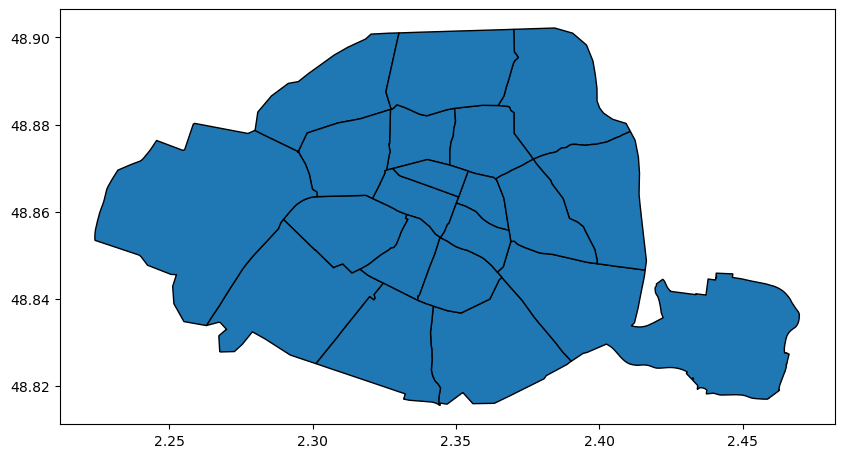

In [29]:
gdf_neigh.plot(figsize=(10, 10), edgecolor='black')

## 2. Affichage des logements sur la carte

#### Nous allons pour cela transformer notre dataframe listings en GeoDataframe

In [30]:
gdf_listings = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude),
    crs="EPSG:4326" ) # système GPS

<Axes: >

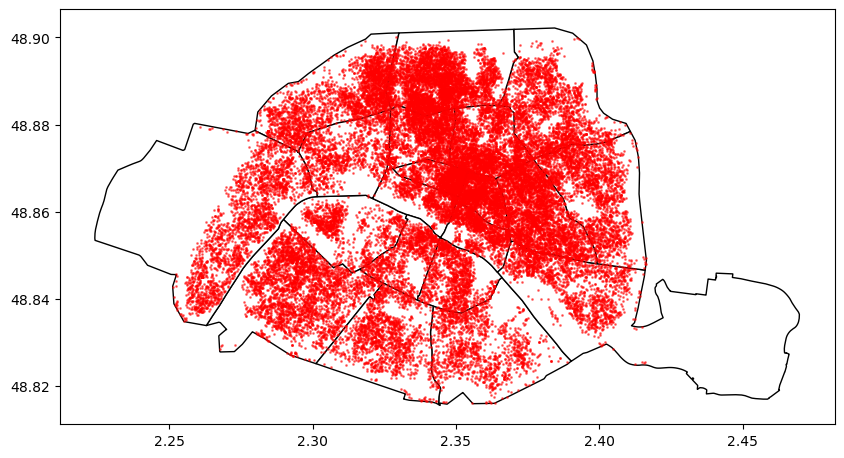

In [31]:
ax = gdf_neigh.plot(figsize=(10, 10), color="white", edgecolor="black")
gdf_listings.plot(ax=ax, markersize=1, color="red", alpha=0.5)

## 3. Récuperation de la Seine via OSM (OpenStreetMap) et ajout de la colonne distance

In [32]:
import osmnx as ox


# Définir les tags pour récupérer les cours d'eau (notamment la Seine)
tags = {"waterway": "river"}

# Télécharger les entités correspondant à ces tags à Paris
gdf = ox.features_from_place("Paris, France", tags=tags)

# Filtrer les entités dont le nom contient 'Seine'
seine = gdf[gdf['name'].str.contains("Seine", na=False)]

# Vérification
print(seine[['name', 'geometry']].head())

                                           name  \
element id                                        
way     32496111                       La Seine   
        99550443                       La Seine   
        99555151          La Seine - Bras Marie   
        99555152  La Seine - Bras de la Monnaie   
        99555154                       La Seine   

                                                           geometry  
element id                                                           
way     32496111  LINESTRING (2.40936 48.81663, 2.40762 48.8174,...  
        99550443  LINESTRING (2.23046 48.86786, 2.23093 48.86814...  
        99555151  LINESTRING (2.3614 48.84847, 2.36095 48.84931,...  
        99555152  LINESTRING (2.35386 48.85119, 2.35325 48.85125...  
        99555154  LINESTRING (2.28874 48.85721, 2.28834 48.85547...  


In [33]:
print("CRS gdf_neigh:", gdf_neigh.crs)
print("CRS seine:", seine.crs)
print("CRS gdf_listings:", gdf_listings.crs)

CRS gdf_neigh: EPSG:4326
CRS seine: epsg:4326
CRS gdf_listings: EPSG:4326


In [34]:
# Reprojection en Lambert 93 (EPSG:2154)
gdf_neigh_proj = gdf_neigh.to_crs(epsg=2154)
seine_proj = seine.to_crs(epsg=2154)
gdf_listings_proj = gdf_listings.to_crs(epsg=2154)

In [35]:
print("Bornes quartiers:", gdf_neigh_proj.total_bounds)
print("Bornes Seine:", seine_proj.total_bounds)
print("Bornes logements:", gdf_listings_proj.total_bounds)

Bornes quartiers: [ 643065.72945475 6857478.61174764  661079.59645316 6867082.55627783]
Bornes Seine: [ 642959.80567831 6857558.49823922  656629.75470821 6867009.69615124]
Bornes logements: [ 645051.87825306 6857525.01367132  657162.5328598  6866874.17168831]


C:\Users\huvelle\AppData\Local\Temp\ipykernel_20456\2014433909.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


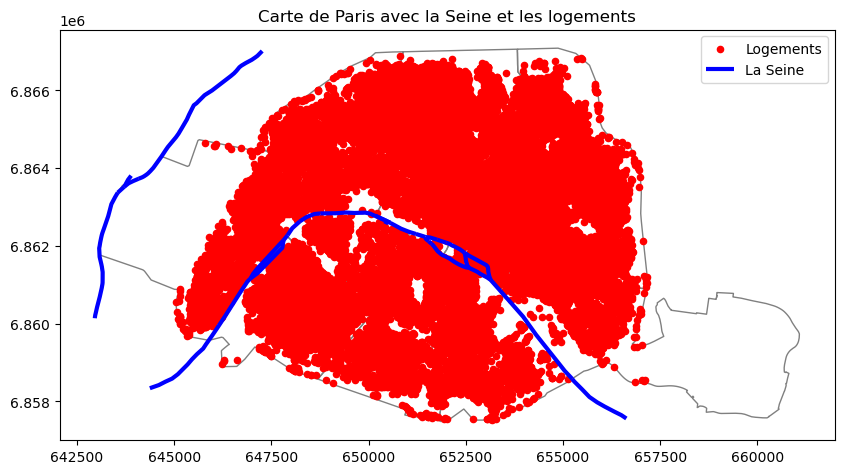

In [36]:
from shapely.ops import unary_union

seine_unie = unary_union(seine_proj.geometry)

fig, ax = plt.subplots(figsize=(10,10))
gdf_neigh_proj.plot(ax=ax, facecolor='none', edgecolor='gray', label='Quartiers')
gdf_listings_proj.plot(ax=ax, color='red', markersize=20, label='Logements')
gpd.GeoSeries(seine_unie).plot(ax=ax, color='blue', linewidth=3, label='La Seine')

plt.legend()
plt.title("Carte de Paris avec la Seine et les logements")
plt.show()

In [37]:
gdf_listings_proj['distance_seine'] = gdf_listings_proj.geometry.apply(lambda x: x.distance(seine_unie))
print(gdf_listings_proj[['distance_seine']].head())

    distance_seine
0       379.074605
1      2352.701981
4      2420.040507
8      2897.446887
10     1257.429697


In [38]:
gdf_listings_proj.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,geometry,distance_seine
0,371299,Hôtel-de-Ville,48.857510,2.355110,Entire home/apt,185.0,307,601,3.97,3,POINT (652683.36 6862134.696),379.074605
1,371862,Entrepôt,48.871510,2.372190,Entire home/apt,250.0,9,50,0.34,4,POINT (653948.898 6863681.289),2352.701981
4,378897,Opéra,48.882850,2.334620,Entire home/apt,110.0,6,28,0.19,3,POINT (651203.753 6864964.785),2420.040507
8,390984,Buttes-Montmartre,48.885738,2.340673,Entire home/apt,155.0,262,425,2.85,3,POINT (651650.326 6865282.19),2897.446887
10,392431,Temple,48.862870,2.365020,Entire home/apt,360.0,55,37,0.27,3,POINT (653415.25 6862724.791),1257.429697


#### Supprimons la colonne 'geometry' et renommons proprement ce Dataset

In [39]:
# 1. Supprimer la colonne 'geometry'
df_enrichi = gdf_listings_proj.drop(columns='geometry')

In [40]:
df_enrichi.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine
0,371299,Hôtel-de-Ville,48.857510,2.355110,Entire home/apt,185.0,307,601,3.97,3,379.074605
1,371862,Entrepôt,48.871510,2.372190,Entire home/apt,250.0,9,50,0.34,4,2352.701981
4,378897,Opéra,48.882850,2.334620,Entire home/apt,110.0,6,28,0.19,3,2420.040507
8,390984,Buttes-Montmartre,48.885738,2.340673,Entire home/apt,155.0,262,425,2.85,3,2897.446887
10,392431,Temple,48.862870,2.365020,Entire home/apt,360.0,55,37,0.27,3,1257.429697


# Partie3: Ajout du prix moyen journalier via calendar (sept 2024)

## 1. Importation du fichier calendar

In [41]:
calendar = pd.read_csv("DATA_sept_2024/calendar.csv.gz", compression='gzip',low_memory=False)

In [42]:
calendar.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,3109,2024-09-11,f,$100.00,NaN,2.0,30.0
1,3109,2024-09-12,f,$100.00,NaN,2.0,30.0
2,3109,2024-09-13,f,$100.00,NaN,2.0,30.0
3,3109,2024-09-14,f,$100.00,NaN,2.0,30.0
4,3109,2024-09-15,f,$100.00,NaN,2.0,30.0


In [43]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34842829 entries, 0 to 34842828
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  object 
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 1.8+ GB


In [44]:
calendar.sample(15)

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
20070844,924117713836102656,2025-01-02,t,$90.00,NaN,2.0,365.0
32318414,1176018387945906740,2024-09-11,f,$230.00,NaN,3.0,365.0
29669417,1135412387554231784,2025-03-04,f,$120.00,NaN,2.0,120.0
32682621,1178816541013802931,2025-01-31,t,$455.00,NaN,3.0,1125.0
26630587,1090434399076596008,2025-08-21,f,$100.00,NaN,30.0,365.0
30385578,1144155342814751885,2024-10-18,f,$200.00,NaN,1.0,365.0
24231568,1042747485771572205,2024-09-12,t,$900.00,NaN,1.0,365.0
15337676,670022470084159736,2024-10-09,f,$220.00,NaN,3.0,1125.0
20747053,938057384753163661,2025-05-11,f,"$5,000.00",NaN,4.0,1125.0
25929067,1079218857048105347,2025-08-12,f,$165.00,NaN,1.0,365.0


In [45]:
calendar.isnull().sum() #sommes des valeurs manquantes par colonne

listing_id               0
date                     0
available                0
price                    0
adjusted_price    34824579
minimum_nights          10
maximum_nights          10
dtype: int64

## 2.Nettoyage du fichier et filtrages

In [46]:
# convertion de la date en datetime
calendar['date'] = pd.to_datetime(calendar['date'])

In [47]:
# Filtrer sur mars 2025 uniquement
calendar = calendar[
    (calendar['date'].dt.month == 3) & 
    (calendar['date'].dt.year == 2025)
] 

In [48]:
# Filtrer les logements disponibles
calendar_dispo = calendar[calendar['available'] == 't'].copy()

In [49]:
# Nettoyons la colonne price
calendar_dispo['price'] = calendar_dispo['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
calendar_dispo['price'] = calendar_dispo['price'].replace('nan', np.nan).astype(float)
calendar_dispo = calendar_dispo[calendar_dispo['price'] > 0]

In [51]:
# Filtrons et gardons les prix inférieurs à 500€
calendar_dispo = calendar_dispo[
    (calendar_dispo['price'] <= 500)
]

In [52]:
# Supprimer colonnes inutiles
calendar_dispo = calendar_dispo.drop(columns=['adjusted_price', 'minimum_nights', 'maximum_nights', 'available'])

## 3. Calculer prix moyen journalier par logement

In [53]:
prix_moyen = calendar_dispo.groupby('listing_id')['price'].mean().reset_index()
prix_moyen.rename(columns={'price': 'prix_moyen_journalier'}, inplace=True)

## 4. Fusion avec le dataframe listings enrichi (avec distance à la Seine, quartier...)

In [54]:
df_final = df_enrichi.merge(prix_moyen, left_on='id', right_on='listing_id', how='left')

In [55]:
df_final.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine,listing_id,prix_moyen_journalier
0,371299,Hôtel-de-Ville,48.857510,2.355110,Entire home/apt,185.0,307,601,3.97,3,379.074605,371299.0,195.0
1,371862,Entrepôt,48.871510,2.372190,Entire home/apt,250.0,9,50,0.34,4,2352.701981,NaN,NaN
2,378897,Opéra,48.882850,2.334620,Entire home/apt,110.0,6,28,0.19,3,2420.040507,NaN,NaN
3,390984,Buttes-Montmartre,48.885738,2.340673,Entire home/apt,155.0,262,425,2.85,3,2897.446887,390984.0,220.0
4,392431,Temple,48.862870,2.365020,Entire home/apt,360.0,55,37,0.27,3,1257.429697,NaN,NaN


In [56]:
# Nettoyons df_final en supprimant colonnes inutiles 
df_final.drop(columns=['listing_id', 'price', 'room_type'], inplace=True )

In [57]:
# vérification
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44102 entries, 0 to 44101
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     44102 non-null  int64  
 1   neighbourhood          44102 non-null  object 
 2   latitude               44102 non-null  float64
 3   longitude              44102 non-null  float64
 4   availability_365       44102 non-null  int64  
 5   number_of_reviews      44102 non-null  int64  
 6   reviews_per_month      33897 non-null  float64
 7   minimum_nights         44102 non-null  int64  
 8   distance_seine         44102 non-null  float64
 9   prix_moyen_journalier  28213 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 3.4+ MB


#### Le fait qu'on ai 14 529 logements sans prix moyen est normal vu les conditions :
#### On travailles uniquement sur sept 2024
#### On ne prends que les logements disponibles
#### Donc si un logement n’est pas dispo en sept, ou qu’il n’a pas de prix renseigné à ces dates → pas de prix moyen.

In [58]:
df_final = df_final[df_final['prix_moyen_journalier'].notna()]

In [59]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28213 entries, 0 to 44101
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     28213 non-null  int64  
 1   neighbourhood          28213 non-null  object 
 2   latitude               28213 non-null  float64
 3   longitude              28213 non-null  float64
 4   availability_365       28213 non-null  int64  
 5   number_of_reviews      28213 non-null  int64  
 6   reviews_per_month      20440 non-null  float64
 7   minimum_nights         28213 non-null  int64  
 8   distance_seine         28213 non-null  float64
 9   prix_moyen_journalier  28213 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 2.4+ MB


#### Enfin, ajoutons une colonne 'période' pour ajouter une variable temporelle à notre projet

In [60]:
df_final['periode'] = 'sept_2024'

In [61]:
df_final_sept2024=df_final.copy()

In [62]:
df_final_sept2024.to_csv("../OUTPUT/listings_sept2024_clean.csv", index=False)